# Downstream analysis of cancer datasets
- Labels are transfered by stGPTNet

In [1]:
from numpy.random import default_rng
import scanpy as sc
from anndata import AnnData
import scipy
sc.logging.print_header()
from sklearn.metrics.cluster import adjusted_rand_score
import numpy as np
import pandas as pd
import seaborn as sns
import os
import torch
import pandas as pd
from sklearn import metrics
import multiprocessing as mp
from sklearn.metrics.cluster import normalized_mutual_info_score
import pickle
import os.path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score

In [2]:
import matplotlib.pyplot as plt
def make_plot(adata, key, w = 6.6, d = 3.5):
    df_spatial = pd.DataFrame(adata.obsm['spatial'])
    df_spatial['region'] = list(adata.obs[key])
    df_spatial['region'] = df_spatial['region'].astype(str)
    df_spatial.columns = ['x', 'y', 'region']
    plt.figure(figsize=(w, d))
    sns.scatterplot(x="x", y="y", hue="region", data=df_spatial, palette="tab10", s=10)
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

from sklearn.manifold import TSNE

def make_tsne_plot(adata, key, w=6.6, d=3.5, tsne_key='X_tsne', random_state=42):
    # If t-SNE not computed yet, compute and store
    if tsne_key not in adata.obsm:
        print(f"[INFO] '{tsne_key}' not found. Computing t-SNE...")
        tsne = TSNE(n_components=2, random_state=random_state)
        tsne_coords = tsne.fit_transform(adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X)
        adata.obsm[tsne_key] = tsne_coords
    
    # Prepare dataframe
    df_tsne = pd.DataFrame(adata.obsm[tsne_key], columns=['x', 'y'])
    df_tsne['region'] = list(adata.obs[key])
    df_tsne['region'] = df_tsne['region'].astype(str)
    
    # Plot
    plt.figure(figsize=(w, d))
    sns.scatterplot(
        x="x", y="y", hue="region",
        data=df_tsne, palette="tab10", s=20
    )
    plt.legend(
        bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.
    )
    plt.tight_layout()
    plt.show()

## Read data and annotation from stGPTNet

In [3]:
# data_dir = '/data/hoan/spatial_transcriptomics/data/DeepGFT/'
# adata=sc.read_h5ad(data_dir)
# Read data
# https://drive.google.com/drive/folders/1kxSSaSVZwddADUtbOgLQs8f9iNEZjxqz?zx=2r66cautuyrj
name = 'Human_Breast_Cancer'
adata = sc.read_visium('/data/hoan/spatial_transcriptomics/GraphBG-analysis/Data/DeepGFT/V1_Breast_Cancer_Block_A_Section_2/', count_file='filtered_feature_bc_matrix.h5')

/tmp/ipykernel_29829/1303937921.py:6: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium('/data/hoan/spatial_transcriptomics/GraphBG-analysis/Data/DeepGFT/V1_Breast_Cancer_Block_A_Section_2/', count_file='filtered_feature_bc_matrix.h5')
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


#### Read embedding and labels 

In [4]:
embedding = pd.read_csv('Data/stGPTNet/emb_test_gpt.csv',index_col=0)
stGPTNet_labels = pd.read_csv('/data/hoan/spatial_transcriptomics/GraphBG-analysis/Data/stGPTNet/y_pred_decoded.csv', delimiter='\t')

adata.obsm["stGPTNet_embedding"] = embedding.values
adata.obs['stGPTNet_labels'] = stGPTNet_labels.iloc[:,0].values

In [5]:
adata.var_names_make_unique()

## Preprocessing data

In [6]:
n_features = adata.shape[1]
if n_features > 5000:
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
sc.pp.scale(adata, zero_center=False, max_value=10)
if n_features > 5000:
    adata =  adata[:, adata.var['highly_variable']]


In [7]:
# Perform PCA
sc.tl.pca(adata, n_comps=50)
adata.obsm['X_pca'].shape
if scipy.sparse.issparse(adata.X):
    adata.obsm['X_feature'] = adata.X.todense() 
else:
    adata.obsm['X_feature'] = adata.X
pca = PCA(n_components=20, random_state=42)
adata.obsm['X_pca'] = pca.fit_transform(np.asarray(adata.obsm['X_feature']))

/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/anndata/_core/aligned_mapping.py:284: ImplicitModificationWarning: Obsm 'X_feature' should not be a np.matrix, use np.ndarray instead.
  return super()._validate_value(val, key)


In [8]:
%load_ext autoreload
%autoreload 2

## PAGA and UMAP

In [9]:
adata.uns["log1p"] = {"base": None}

In [10]:
adata_origin = adata.copy()

In [11]:
class_counts = adata.obs["stGPTNet_labels"].value_counts()

In [12]:
min_freq = 100

# Classes to keep
keep_classes = class_counts[class_counts >= min_freq].index

# Filter cells
adata = adata_origin[
    adata_origin.obs["stGPTNet_labels"].isin(keep_classes)
].copy()

print(f"Original cells: {adata_origin.n_obs:,}")
print(f"Filtered cells: {adata.n_obs:,}")
print(f"Removed cells: {adata_origin.n_obs - adata.n_obs:,}")

Original cells: 3,987
Filtered cells: 3,811
Removed cells: 176


In [13]:
import scanpy as sc

sc.pp.neighbors(
    adata,
    use_rep="stGPTNet_embedding",
    n_neighbors=15,
    metric="cosine"
)

/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


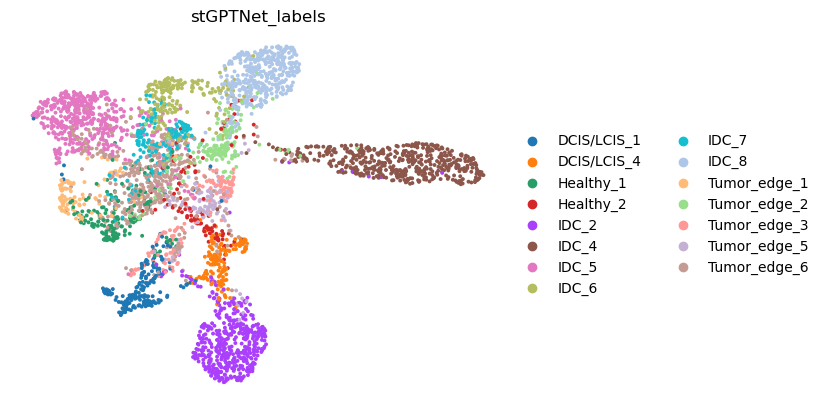

In [14]:
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="stGPTNet_labels",
    frameon=False
)

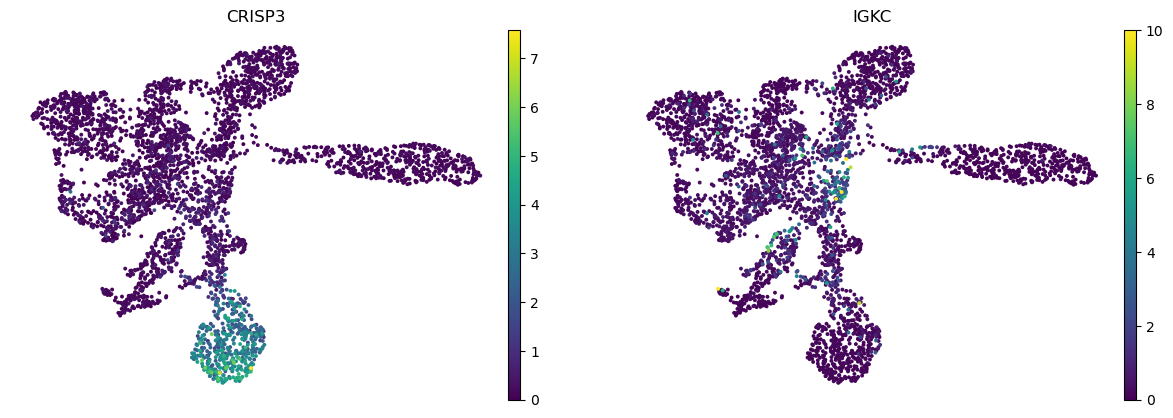

In [15]:
sc.pl.umap(
    adata,
    color=["CRISP3", "IGKC"],
    frameon=False
)

In [16]:
sc.tl.paga(
    adata,
    groups="stGPTNet_labels"
)

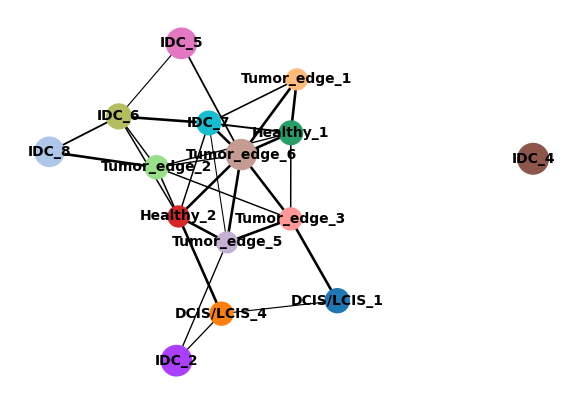

In [17]:
sc.pl.paga(
    adata,
    threshold=0.4,
    frameon=False,
    node_size_scale=2,
    edge_width_scale=0.25,
    solid_edges="connectivities",
    layout="fr",
)

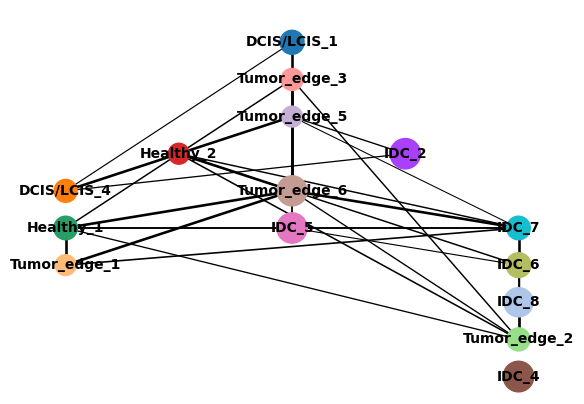

In [18]:
sc.pl.paga(
        adata,
        threshold=0.4, 
        frameon=False,
        layout="rt",
        edge_width_scale=0.25,
        node_size_scale=2,
    )

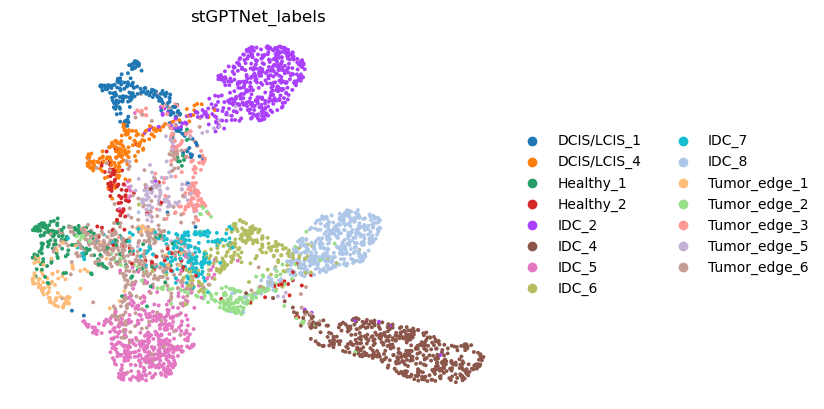

In [19]:
sc.tl.umap(
    adata,
    init_pos="paga"
)

sc.pl.umap(
    adata,
    color="stGPTNet_labels",
    frameon=False
)

/tmp/ipykernel_29829/3615117762.py:12: FutureWarning: Use `squidpy.read.visium` instead.
  adata_train = sc.read_visium(
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


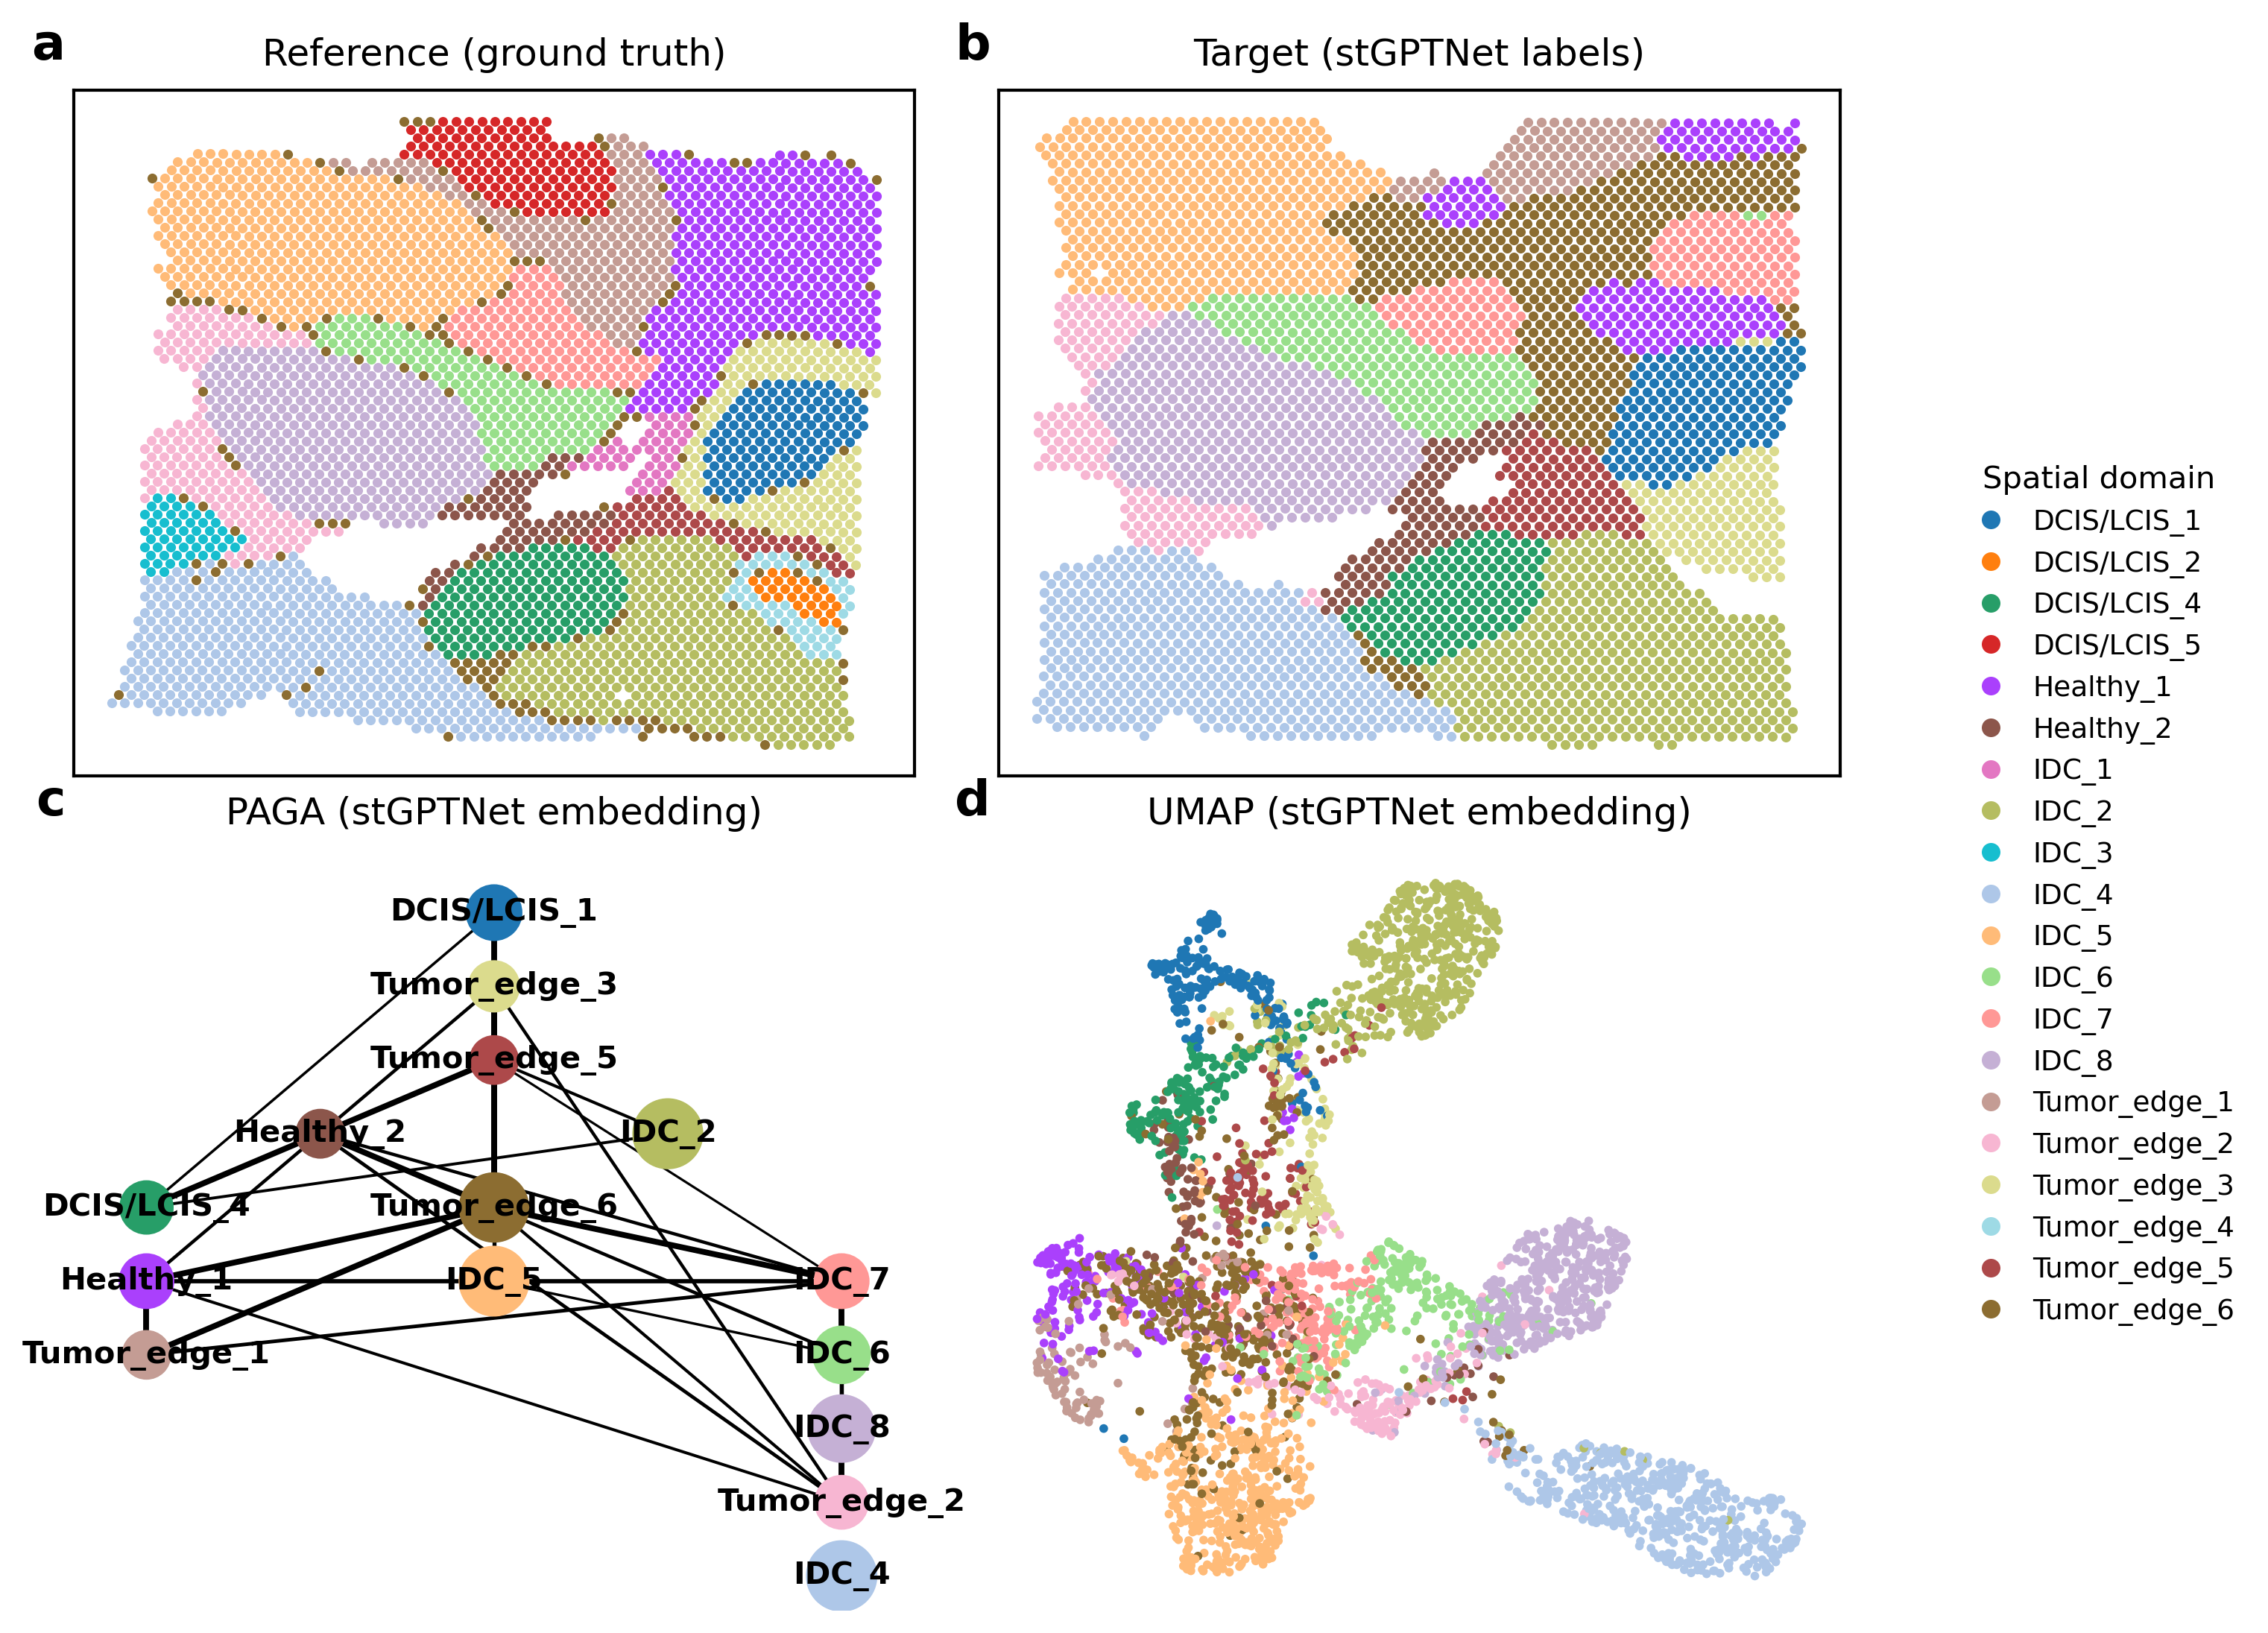

In [20]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ============================================================
# 1. Load training data and ground truth
# ============================================================
adata_train = sc.read_visium(
    '/data/hoan/spatial_transcriptomics/GraphBG-analysis/Data/DeepGFT/'
    'V1_Breast_Cancer_Block_A_Section_1',
    count_file='filtered_feature_bc_matrix.h5'
)

ground_truth_df = pd.read_csv(
    '/data/hoan/spatial_transcriptomics/GraphBG-analysis/Data/DeepGFT/'
    'V1_Breast_Cancer_Block_A_Section_1/metadata.tsv',
    delimiter='\t',
    index_col=0
)

adata_train.obs["ground_truth"] = (
    ground_truth_df.loc[
        adata_train.obs_names,
        "ground_truth"
    ].astype(str)
)


# ============================================================
# 2. Labels
# ============================================================
ground_truth = "ground_truth"
label_key = "stGPTNet_labels"

y_train = adata_train.obs[ground_truth].astype(str)
y_pred = adata.obs[label_key].astype(str)


# ============================================================
# 3. GLOBAL label set
#
# Includes classes appearing in either dataset.
# ============================================================
all_labels = sorted(
    set(y_train.unique()).union(
        set(y_pred.unique())
    ),
    key=lambda x: str(x)
)

# ============================================================
# 4. Scanpy default categorical palette
# ============================================================
palette = list(sc.pl.palettes.default_20)

if len(all_labels) > len(palette):
    raise ValueError(
        f"{len(all_labels)} classes found, but "
        f"default_20 only contains {len(palette)} colors."
    )


# ============================================================
# 5. GLOBAL label -> color mapping
# ============================================================
colors = {
    label: palette[i]
    for i, label in enumerate(all_labels)
}


# ============================================================
# 6. IMPORTANT:
#    Keep ONLY the actual classes in adata for PAGA/UMAP
# ============================================================
adata.obs[label_key] = (
    adata.obs[label_key]
    .astype(str)
)

adata.obs[label_key] = pd.Categorical(
    adata.obs[label_key],
    categories=sorted(
        adata.obs[label_key].unique(),
        key=lambda x: str(x)
    )
)


# ============================================================
# 7. Tell Scanpy to use the GLOBAL colors
#    but ONLY for labels actually present in adata
# ============================================================
adata_labels = list(
    adata.obs[label_key].cat.categories
)

adata.uns[f"{label_key}_colors"] = [
    colors[label]
    for label in adata_labels
]


# ============================================================
# 8. PAGA
# ============================================================
sc.tl.paga(
    adata,
    groups=label_key
)


# ============================================================
# 9. UMAP initialized from PAGA
# ============================================================
sc.tl.umap(
    adata,
    init_pos="paga"
)


# ============================================================
# 10. Spatial plotting function
# ============================================================
def plot_spatial(
    ax,
    adata_obj,
    labels,
    title
):

    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------
    coordinates = pd.DataFrame(
        adata_obj.obsm["spatial"],
        columns=["x", "y"],
        index=adata_obj.obs_names
    )

    coordinates["region"] = (
        np.asarray(labels).astype(str)
    )

    # Flip y-axis
    coordinates["y"] = (
        coordinates["y"].max()
        - coordinates["y"]
    )

    # --------------------------------------------------------
    # Plot using GLOBAL colors
    # --------------------------------------------------------
    regions = [
        region
        for region in all_labels
        if region in coordinates["region"].unique()
    ]

    for region in regions:

        sub = coordinates[
            coordinates["region"] == region
        ]

        ax.scatter(
            sub["x"],
            sub["y"],
            s=10,
            c=[colors[region]],
            # marker="o",
            linewidths=0,
            # alpha=0.9,
            # rasterized=True
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    # ax.set_aspect("equal")

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks([])
    ax.set_yticks([])

    # for spine in ax.spines.values():
    #     spine.set_visible(False)

    # Add a rectangular box around the subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

    ax.set_title(
        title,
        fontsize=12,
        pad=8
    )


# ============================================================
# 11. Create 2 × 2 figure
# ============================================================
# fig, axes = plt.subplots(
#     2,
#     2,
#     figsize=(8.5, 8.0),
#     dpi=300
# )
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    dpi=300,
    gridspec_kw={
        "height_ratios": [0.9, 1.0]
    }
)


# ============================================================
# (a) Ground truth
# ============================================================
plot_spatial(
    axes[0, 0],
    adata_train,
    y_train,
    title="Reference (ground truth)"
)


# ============================================================
# (b) stGPTNet
# ============================================================
plot_spatial(
    axes[0, 1],
    adata,
    y_pred,
    title="Target (stGPTNet labels)"
)


# ============================================================
# (c) PAGA
# ============================================================
sc.pl.paga(
    adata,
    threshold=0.4,
    frameon=False,
    layout="rt",
    edge_width_scale=0.25,
    node_size_scale=2,
    color=label_key,
    ax=axes[1, 0],
    show=False
)

axes[1, 0].set_title(
    "PAGA (stGPTNet embedding)",
    fontsize=12,
    pad=8
)


# ============================================================
# (d) UMAP
# ============================================================
sc.pl.umap(
    adata,
    color=label_key,
    frameon=False,
    ax=axes[1, 1],
    show=False,
    legend_loc=None
)

axes[1, 1].set_title(
    "UMAP (stGPTNet embedding)",
    fontsize=12,
    pad=8
)


# ============================================================
# 12. Panel labels
# ============================================================
for ax, label in zip(
    axes.flat,
    ["a", "b", "c", "d"]
):
    ax.text(
        -0.01,
        1.03,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="bottom",
        ha="right"
    )


# ============================================================
# 13. Shared legend
# ============================================================
handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=colors[region],
        markeredgecolor="none",
        markersize=6,
        label=region
    )
    for region in all_labels
]

fig.legend(
    handles=handles,
    title="Spatial domain",
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False,
    handletextpad=0.5,
    borderaxespad=0,
    fontsize=9,
    title_fontsize=10
)


# ============================================================
# 14. Final layout
# ============================================================
plt.subplots_adjust(
    left=0.04,
    right=0.83,
    bottom=0.1,
    top=0.95,
    wspace=0.1,
    hspace=0.1
)
# fig.set_size_inches(8.5, 7.0)
fig.savefig(
    "/data/hoan/spatial_transcriptomics/GraphBG-analysis/"
    "output/paga_umap.pdf",
    bbox_inches="tight",
    format="pdf"
)

plt.show()

### Patterns from PAGA and UMAP analysis:
- Development Trajectory 1  (Healty -> Tumor Edges -> Tumor Core) : Healthy 1, 2 -> Tumor Edges 1, 6 -> ICD 7, 6, 8-> IDC 4
- Development Trajectory 2 (Healty -> DCIS/LCIS -> IDC): Healthy 2 -> DCIS/LCIS_4 -> DCIS/LCIS_1 

## Cell–cell communication analysis

#### Cell2cell communications with LIANA

In [21]:
import scanpy as sc
import squidpy as sq
import liana as li

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

cluster_key = "stGPTNet_labels"

# Work on a copy
adata_ccc = adata.copy()

# Make labels categorical
adata_ccc.obs[cluster_key] = (
    adata_ccc.obs[cluster_key]
    .astype(str)
    .astype("category")
)

# Cluster sizes
cluster_sizes = (
    adata_ccc.obs[cluster_key]
    .value_counts()
    .sort_values(ascending=False)
)

print(cluster_sizes)

/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


stGPTNet_labels
IDC_4           490
IDC_2           476
IDC_5           471
Tumor_edge_6    458
IDC_8           410
IDC_6           212
DCIS/LCIS_1     185
IDC_7           173
Healthy_1       172
Tumor_edge_2    160
DCIS/LCIS_4     155
Tumor_edge_3    131
Healthy_2       107
Tumor_edge_5    106
Tumor_edge_1    105
Name: count, dtype: int64


In [22]:
min_cells = 50

valid_clusters = cluster_sizes[
    cluster_sizes >= min_cells
].index

adata_ccc = adata_ccc[
    adata_ccc.obs[cluster_key].isin(valid_clusters)
].copy()

print(f"Cells retained: {adata_ccc.n_obs:,}")
print(f"Clusters retained: {adata_ccc.obs[cluster_key].nunique()}")

Cells retained: 3,811
Clusters retained: 15


In [23]:
# adata_ccc.X.todense()

In [24]:
li.mt.rank_aggregate(
    adata_ccc,
    groupby=cluster_key,
    resource_name="consensus",
    expr_prop=0.10,
    use_raw=False,
    n_perms=1000,
    seed=1234,
    n_jobs=-1,
    verbose=True
)

# # Spatially informed LIANA
# li.mt.rank_aggregate(
#     adata_ccc,
#     groupby=cluster_key,
#     resource_name="consensus",
#     expr_prop=0.10,
#     use_raw=False,
#     spatial_key="spatial",
#     spatial_kwargs={
#         "kernel": "gaussian",
#         "bandwidth": 100
#     },
#     n_perms=1000,
#     seed=1234,
#     n_jobs=-1,
#     verbose=True
# )

Using resource `consensus`.
Using `.X`!
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.68 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 3811 samples and 386 features
Assuming that counts were `natural` log-normalized!


/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/vanhoan310/miniconda3/envs/biopy311/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Running CellPhoneDB


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:08<00:00, 111.90it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [25]:
ccc = adata_ccc.uns["liana_res"].copy()

In [26]:
# Run LIANA consensus analysis
# The consensus method combines multiple LR inference methods and produces the aggregate magnitude_rank and specificity_rank.
ccc["magnitude_rank"] = pd.to_numeric(
    ccc["magnitude_rank"],
    errors="coerce"
)

ccc["specificity_rank"] = pd.to_numeric(
    ccc["specificity_rank"],
    errors="coerce"
)

high_conf = ccc[
    (ccc["magnitude_rank"] <= 0.10) &
    (ccc["specificity_rank"] <= 0.10)
].copy()

print(f"High-confidence interactions: {len(high_conf):,}")

High-confidence interactions: 3,865


In [27]:
top_lr = (
    ccc.sort_values(
        ["magnitude_rank", "specificity_rank"],
        ascending=[True, True]
    )
)

top_lr[
    [
        "source",
        "target",
        "ligand_complex",
        "receptor_complex",
        "magnitude_rank",
        "specificity_rank",
        "cellphone_pvals"
    ]
].head(10)

,source,target,ligand_complex,receptor_complex,magnitude_rank,specificity_rank,cellphone_pvals
46528,Tumor_edge_2,Tumor_edge_2,APOE,LRP1,1.006812e-08,2.006274e-07,0.0
50216,Tumor_edge_3,IDC_8,C3,IFITM1,1.006812e-08,3.668794e-07,0.0
50773,Tumor_edge_3,Tumor_edge_2,C3,LRP1,2.265303e-08,3.029671e-08,0.0
46829,Tumor_edge_2,Tumor_edge_3,APOE,LRP1,6.292367e-08,8.965719e-06,0.0
46537,Tumor_edge_2,Tumor_edge_2,C1QB,LRP1,1.233276e-07,1.170397e-05,0.0
51996,Tumor_edge_5,DCIS/LCIS_1,COL1A1,DDR1,1.610792e-07,1.211077e-03,0.0
52006,Tumor_edge_5,DCIS/LCIS_1,COL3A1,DDR1,2.038636e-07,1.211077e-03,0.0
49037,Tumor_edge_3,IDC_4,C3,IFITM1,2.516806e-07,6.220807e-05,0.0
47160,Tumor_edge_2,Tumor_edge_5,APOE,LRP1,4.253261e-07,2.038396e-05,0.0
53855,Tumor_edge_5,IDC_6,COL1A1,DDR1,4.253261e-07,1.211077e-03,0.0


In [28]:
top_lr.head(100).to_csv(
    "output/LIANA_top100_LR_interactions.csv",
    index=False
)

In [29]:
# Find dominant sender → receiver interactions
sender_receiver = (
    high_conf
    .groupby(["source", "target"])
    .agg(
        n_LR=("ligand_complex", "size"),
        mean_magnitude=("magnitude_rank", "mean"),
        mean_specificity=("specificity_rank", "mean"),
        best_magnitude=("magnitude_rank", "min")
    )
    .reset_index()
)

In [30]:
sender_receiver = sender_receiver.sort_values(
    ["n_LR", "mean_magnitude"],
    ascending=[False, True]
)

sender_receiver.head(10)

,source,target,n_LR,mean_magnitude,mean_specificity,best_magnitude
187,Tumor_edge_3,Tumor_edge_3,91,0.027390,0.009357,2.908650e-06
172,Tumor_edge_2,Tumor_edge_3,88,0.031644,0.007578,6.292367e-08
186,Tumor_edge_3,Tumor_edge_2,84,0.028950,0.008110,2.265303e-08
171,Tumor_edge_2,Tumor_edge_2,75,0.024829,0.008664,1.006812e-08
202,Tumor_edge_5,Tumor_edge_3,73,0.037731,0.010716,9.060801e-04
173,Tumor_edge_2,Tumor_edge_5,67,0.035141,0.009668,4.253261e-07
188,Tumor_edge_3,Tumor_edge_5,66,0.030734,0.008776,7.066320e-06
201,Tumor_edge_5,Tumor_edge_2,63,0.027122,0.005325,1.414678e-05
203,Tumor_edge_5,Tumor_edge_5,55,0.036189,0.008258,4.191409e-04
156,Tumor_edge_1,Tumor_edge_2,51,0.025506,0.009757,7.605949e-05


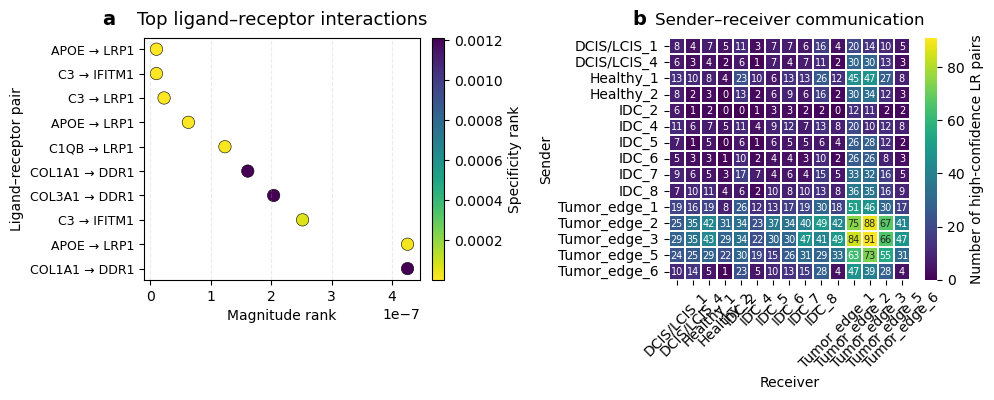

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Top ligand–receptor interactions
# ============================================================
top_lr = (
    ccc.sort_values(
        ["magnitude_rank", "specificity_rank"],
        ascending=[True, True]
    )
    .head(10)
    .copy()
)

# Create readable LR labels
top_lr["LR"] = (
    top_lr["ligand_complex"].astype(str)
    + " → "
    + top_lr["receptor_complex"].astype(str)
)

# ============================================================
# 2. Sender → receiver aggregation
# ============================================================
sender_receiver = (
    high_conf
    .groupby(["source", "target"])
    .agg(
        n_LR=("ligand_complex", "size"),
        mean_magnitude=("magnitude_rank", "mean"),
        mean_specificity=("specificity_rank", "mean"),
        best_magnitude=("magnitude_rank", "min")
    )
    .reset_index()
)

sender_receiver = sender_receiver.sort_values(
    ["n_LR", "mean_magnitude"],
    ascending=[False, True]
)

# Heatmap matrix
sr_matrix = (
    sender_receiver
    .pivot(
        index="source",
        columns="target",
        values="n_LR"
    )
    .fillna(0)
)


# ============================================================
# 3. Figure
# ============================================================
# fig, axes = plt.subplots(
#     1,
#     2,
#     figsize=(15, 6),
#     gridspec_kw={"width_ratios": [1.05, 1.25]}
# )
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    # gridspec_kw={"width_ratios": [1.05, 1.25]}
)


# ============================================================
# 4. LEFT: Top LR interactions
# ============================================================
ax = axes[0]

plot_df = top_lr.iloc[::-1].copy()

# Horizontal dot plot
scatter = ax.scatter(
    plot_df["magnitude_rank"],
    np.arange(len(plot_df)),
    s=80,
    c=plot_df["specificity_rank"],
    cmap="viridis_r",
    edgecolor="black",
    linewidth=0.4
)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["LR"], fontsize=9)

ax.set_xlabel("Magnitude rank", fontsize=10)
ax.set_ylabel("Ligand–receptor pair", fontsize=10)

ax.set_title(
    "Top ligand–receptor interactions",
    fontsize=13,
    pad=10
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# Colorbar
cbar = fig.colorbar(
    scatter,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Specificity rank",
    fontsize=10
)


# ============================================================
# 5. RIGHT: Sender → receiver heatmap
# ============================================================
ax = axes[1]

sns.heatmap(
    sr_matrix,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    square=True,
    annot=True,
    fmt=".0f",
    annot_kws={"fontsize": 7},
    cbar_kws={
        "label": "Number of high-confidence LR pairs"
    },
    ax=ax
)

ax.set_xlabel(
    "Receiver",
    fontsize=10
)

ax.set_ylabel(
    "Sender",
    fontsize=10
)

ax.set_title(
    "Sender–receiver communication",
    fontsize=12,
    pad=10
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.tick_params(
    axis="y",
    rotation=0
)


# ============================================================
# 6. Panel labels
# ============================================================
for ax, label in zip(
    axes,
    ["a", "b"]
):
    ax.text(
        -0.15,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom"
    )


# ============================================================
# 7. Final layout
# ============================================================
plt.tight_layout()

fig.savefig(
    "output/LIANA_cell_cell_communication.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [32]:
# Identify major senders
sender_activity = (
    high_conf
    .groupby("source")
    .agg(
        outgoing_LRs=("ligand_complex", "size"),
        target_domains=("target", "nunique"),
        mean_specificity=("specificity_rank", "mean")
    )
    .sort_values(
        "outgoing_LRs",
        ascending=False
    )
)

sender_activity

,outgoing_LRs,target_domains,mean_specificity
source,,,
Tumor_edge_3,677,15,0.013201
Tumor_edge_2,663,15,0.012603
Tumor_edge_5,505,15,0.012470
Tumor_edge_1,341,15,0.014366
Healthy_1,265,15,0.019288
Tumor_edge_6,246,15,0.019190
IDC_8,185,15,0.023999
IDC_7,167,15,0.024385
Healthy_2,146,14,0.026850


In [33]:
# Identify major receivers
receiver_activity = (
    high_conf
    .groupby("target")
    .agg(
        incoming_LRs=("receptor_complex", "size"),
        source_domains=("source", "nunique"),
        mean_specificity=("specificity_rank", "mean")
    )
    .sort_values(
        "incoming_LRs",
        ascending=False
    )
)

receiver_activity

,incoming_LRs,source_domains,mean_specificity
target,,,
Tumor_edge_3,604,15,0.010209
Tumor_edge_2,598,15,0.010639
Tumor_edge_5,374,15,0.014459
IDC_8,305,15,0.023550
IDC_2,250,14,0.022464
IDC_7,215,15,0.018626
Healthy_1,193,15,0.016831
Tumor_edge_1,193,14,0.018495
IDC_6,191,15,0.022344
